In [14]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from matplotlib.colors import TwoSlopeNorm
import scienceplots
import matplotlib.colors as colors
import matplotlib.ticker as ticker
from qutip import *

## Get Ramsey data

In [63]:
RIDs = ['56745','56746','56747','56748','56749','56750']
ts = np.array([10e-6,200e-6,400e-6,600e-6,800e-6, 1000e-6])
cs = np.array(())
δcs = np.array(())

56745
0.9760921194309187 0.48804845904037875 0.009499695545023772
56746
0.9150244171565449 0.4575141125366851 0.01334993442990063
56747
0.8528224415950695 0.426412737564668 0.01419888743425702
56748
0.6065547614024056 -0.3032787669638138 0.013683524169669338
56749
0.41974160447582753 -0.20987152664038472 0.014091013947944951
56750
0.3027964002753293 0.15139888377627994 0.012322709646805338


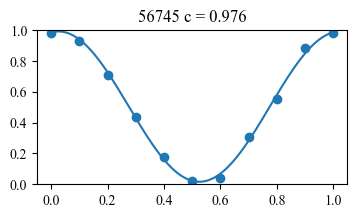

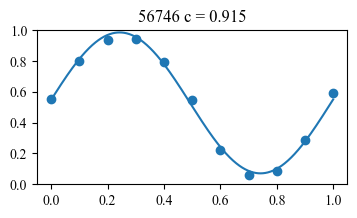

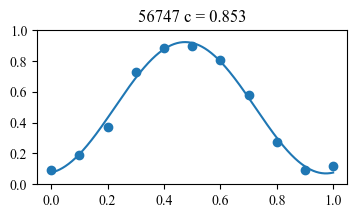

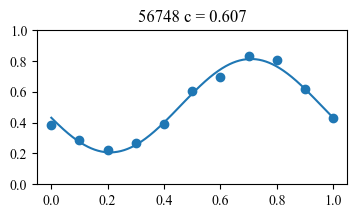

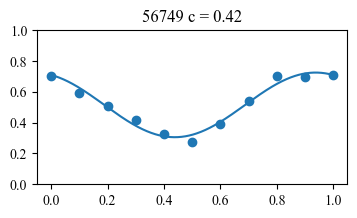

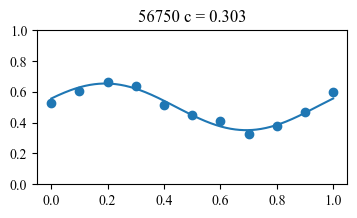

In [64]:
for RID in RIDs:
    print(RID)
    x,p = useful_funcs.get_data(useful_funcs.get_path(RID,day = '2024-12-18'))
    params0 = [1,0,0]
    params, fit, error = useful_funcs.fitSin(x,p,params0)
    c0 = max(fit[1]) - min(fit[1])
    print(c0, params[0], error[0])
    plt.figure(dpi = 100, figsize = (4,2))
    plt.scatter(x,p)
    plt.plot(*fit)
    plt.ylim(0,1)
    plt.title(RID + ' c = ' + str(round(c0,3)))
    
    cs = np.append(cs, c0)
    δcs = np.append(δcs, 2*error[0])

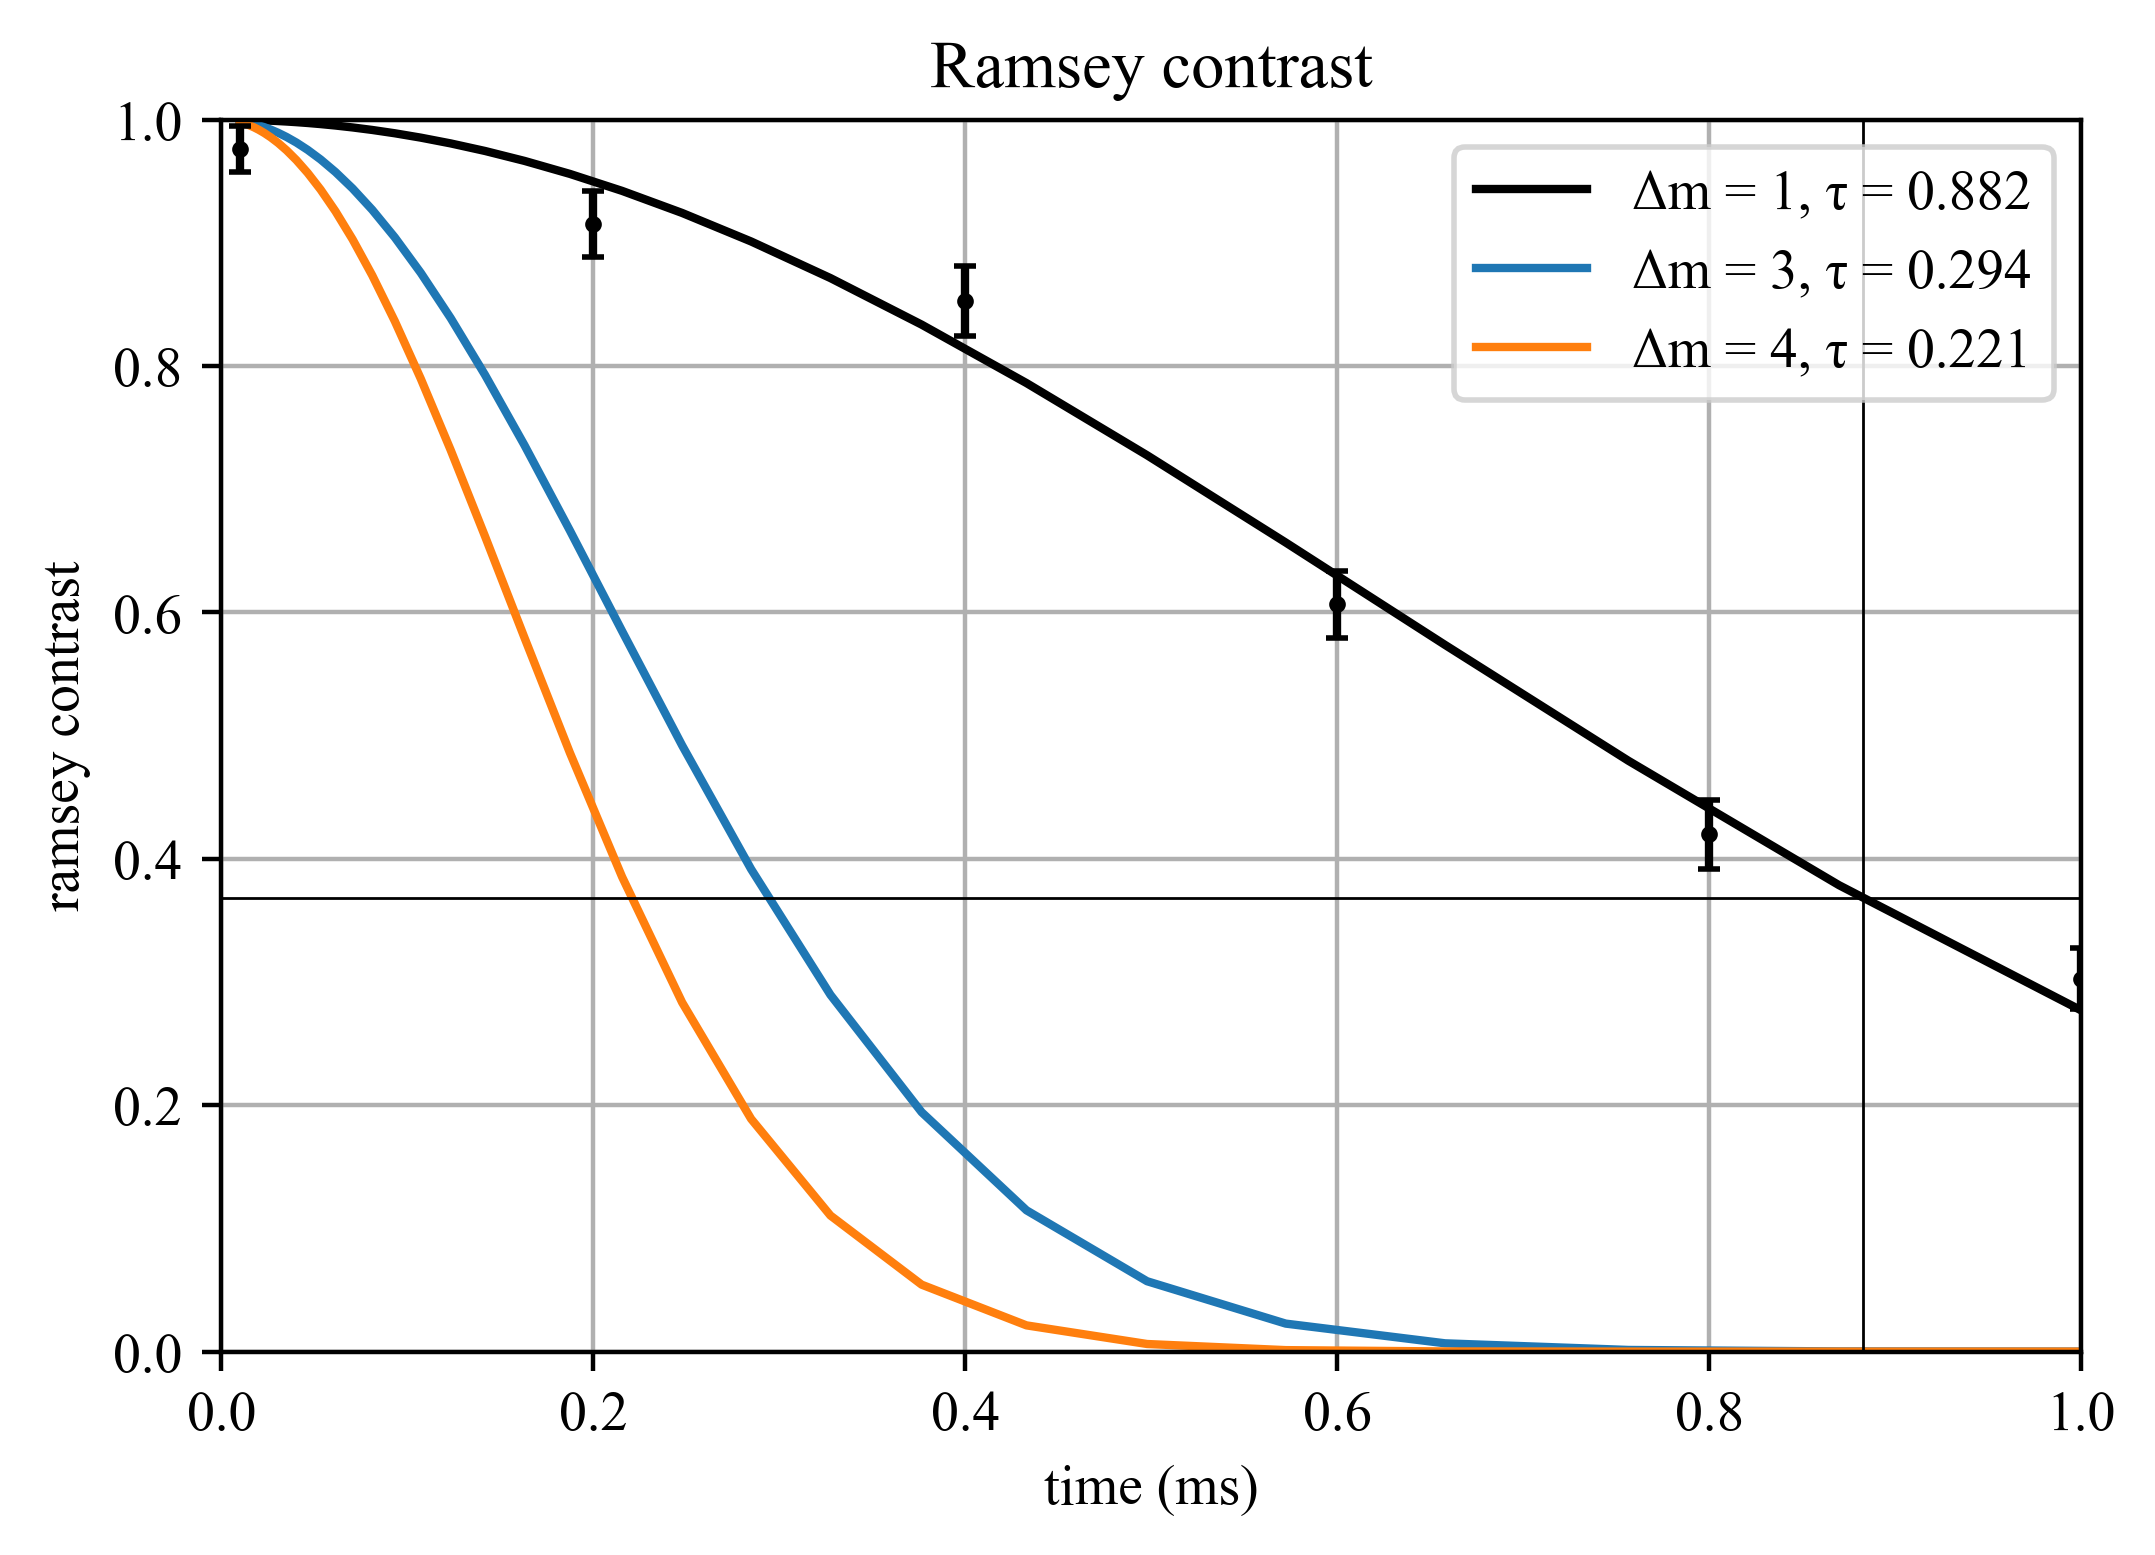

In [65]:
σ1 = 4e-4
σ3 = σ1/3
σ4 = σ1/4

t_fit = np.logspace(-5,1,100)
y_fit1 = np.exp((-.5*(t_fit/σ1)**2))

p1, fit1, error1 = useful_funcs.fitGaus(ts,cs,[σ1])
δ = p1[0]*1e3*(2**.5)

σ1 = p1[0]
σ3 = σ1/3
σ4 = σ1/4

plt.figure(figsize = (6,4), dpi = 400)
plt.ylim(0,1)

plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ1), color = 'black', label = 'Δm = 1, τ = '+ str(round(δ,3)))
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ3), label = 'Δm = 3, τ = '+ str(round(δ/3,3)))
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ4), label = 'Δm = 4, τ = '+ str(round(δ/4,3)))
plt.errorbar(ts*1e3, cs, δcs, marker = '.', color = 'black', ls='none', markersize=4, capsize=2)

plt.title('Ramsey contrast')
plt.xlabel('time (ms)')
plt.ylabel('ramsey contrast')
plt.xlim(0,1)
plt.grid()

plt.axhline(1/np.exp(1), color = 'black', linewidth = .5)
plt.axvline(p1[0]*1e3*(2**.5), color = 'black', linewidth = .5)

plt.legend()

## simulating normally distributed state qubit errors

In [66]:
def carrier(ψ0, θ, ϕ, δ, Ω = 100e3):
    H1 = (Ω/2)*sigmap()*np.exp(-1j*ϕ)
    H2 = (Ω/2)*sigmam()*np.exp(1j*ϕ)
    def H1_t(t,args):
        δ = args['δ']
        return(np.exp(-1j*δ*t))
    def H2_t(t,args):
        δ = args['δ']
        return(np.exp(1j*δ*t))
    args = {'δ':δ}
    H_tot = [[H1,H1_t],[H2,H2_t]]
    t = np.linspace(0,θ/Ω, 2)
    ψ = mesolve(H_tot, ψ0, t, args = args).states[-1]
    return ψ

def delay(ψ0, δ, T):
    # for a static qubit error δ, operates for time T, causing phase error
    H = (δ/2)*sigmaz()
    t = np.linspace(0,T,2)
    ψ = mesolve(H, ψ0, t).states[-1]
    return ψ

def ramsey(T, ϕ, δ):
    # single ion ramsey sequence
    ψ0 = basis(2,0)
    ψ1 = carrier(ψ0, np.pi/2, 0, δ)
    ψ2 = delay(ψ1, δ, T)
    ψ3 = carrier(ψ2, np.pi/2, ϕ, δ)
    return np.abs(ψ3[1][0][0])**2

def phaseScan(T, σ):
    # for each phase, completes ramsey sequence
    ϕ_bank = np.linspace(0,2*np.pi, 20)
    δ_bank = np.linspace(-3*σ, 3*σ, 20)
    δ_bank2 = np.linspace(-3*σ, 3*σ, 200)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    weight_bank2 = np.exp(-(δ_bank2**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank2**2)/(2*(σ**2))))
    pop = np.array(())
    for ϕ in ϕ_bank:
        if ϕ == 0 and T == 0:
            plt.figure(dpi = 400, figsize = (2,1))
            plt.xlim(-20,20)
            plt.scatter(δ_bank*1e-3, weight_bank,label = 'σ = '+str(round(σ*1e-3, 3)) + ' kHz', color = 'black', marker = 'x',s=15)
            plt.plot(δ_bank2*1e-3, weight_bank2*max(weight_bank)/max(weight_bank2),color = 'black')
            plt.xlabel('qubit error δ')
            plt.yticks([])
            plt.title('σ = '+str(round(σ*1e-3, 3)) + ' kHz')
        p = 0
        for i in range(len(δ_bank)):
            p = p + ramsey(T,ϕ, δ_bank[i])*weight_bank[i]
        pop = np.append(pop, p)
    c = max(pop)- min(pop)
    return(c)

def contrastScan(T_max, σ):
    # for each t, runs a phase scan and calculates the contrast
    T_bank = np.linspace(0, T_max, 50)
    c_bank = np.array(())
    for T in T_bank:
        c_bank = np.append(c_bank, phaseScan(T, σ))
    return T_bank, c_bank

def decoherenceFlopping(tmax, σ, Ω = 100e3):
    #Rabi flopping, weighted average over normally distributed qubit error
    δ_bank = np.linspace(-3*σ, 3*σ, 20)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    p = np.array(())
    t_bank = np.linspace(0,tmax, 100)
    for t in t_bank:
        p_temp = 0 
        for i in range(len(δ_bank)):
            ψ0 = basis(2,0)
            p_temp = p_temp + weight_bank[i]*np.abs(carrier(ψ0, Ω*t, 0, δ_bank[i], Ω = Ω)[1][0][0])**2
        p = np.append(p,p_temp)
    return t_bank, p

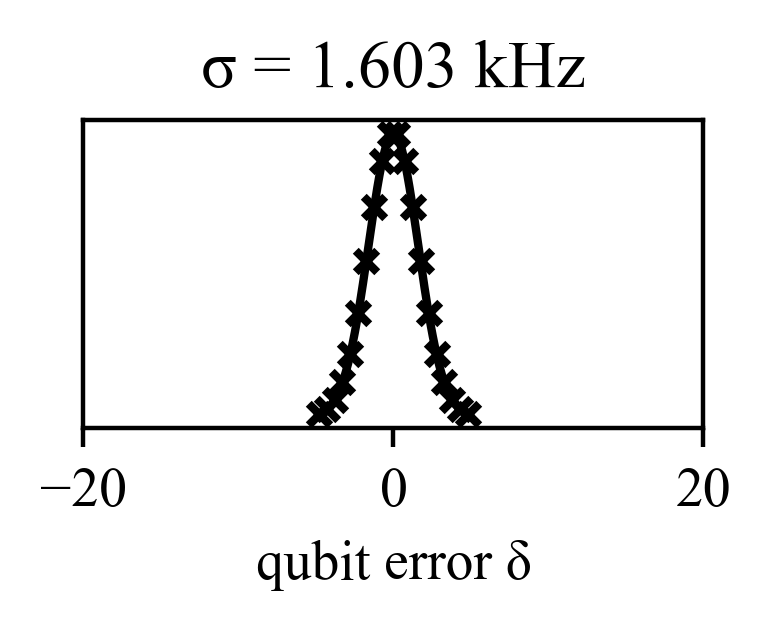

In [53]:
σ = 1/σ1
sim1 = contrastScan(1e-3, σ)

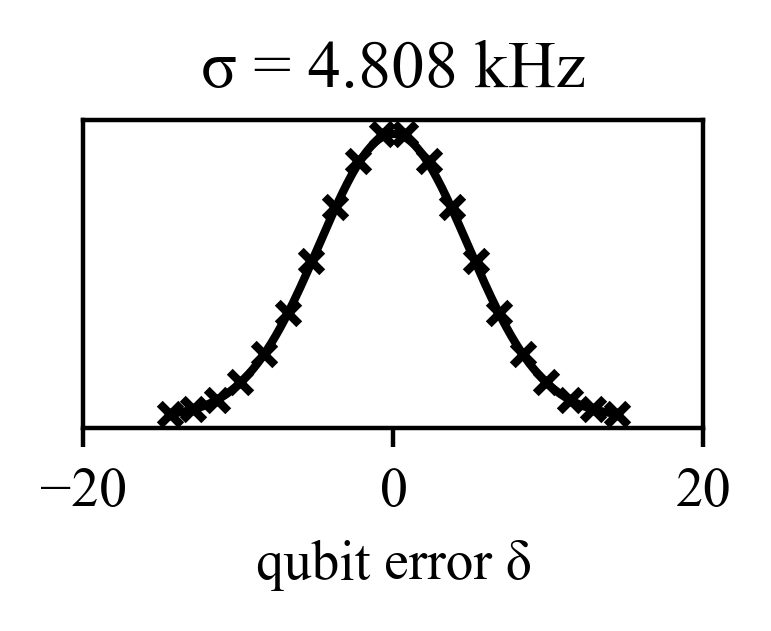

In [54]:
sim3 = contrastScan(1e-3, 1/σ3)

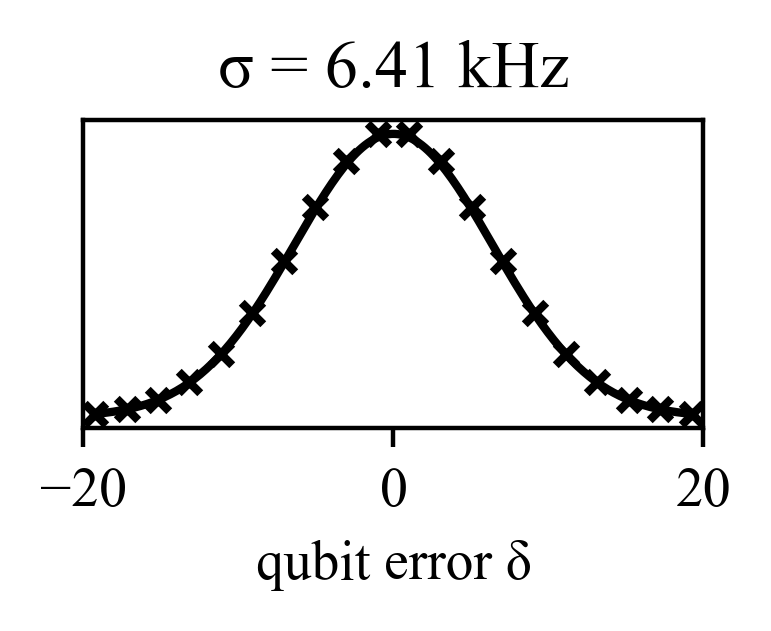

In [55]:
sim4 = contrastScan(1e-3, 1/σ4)

(0.0, 1.0)

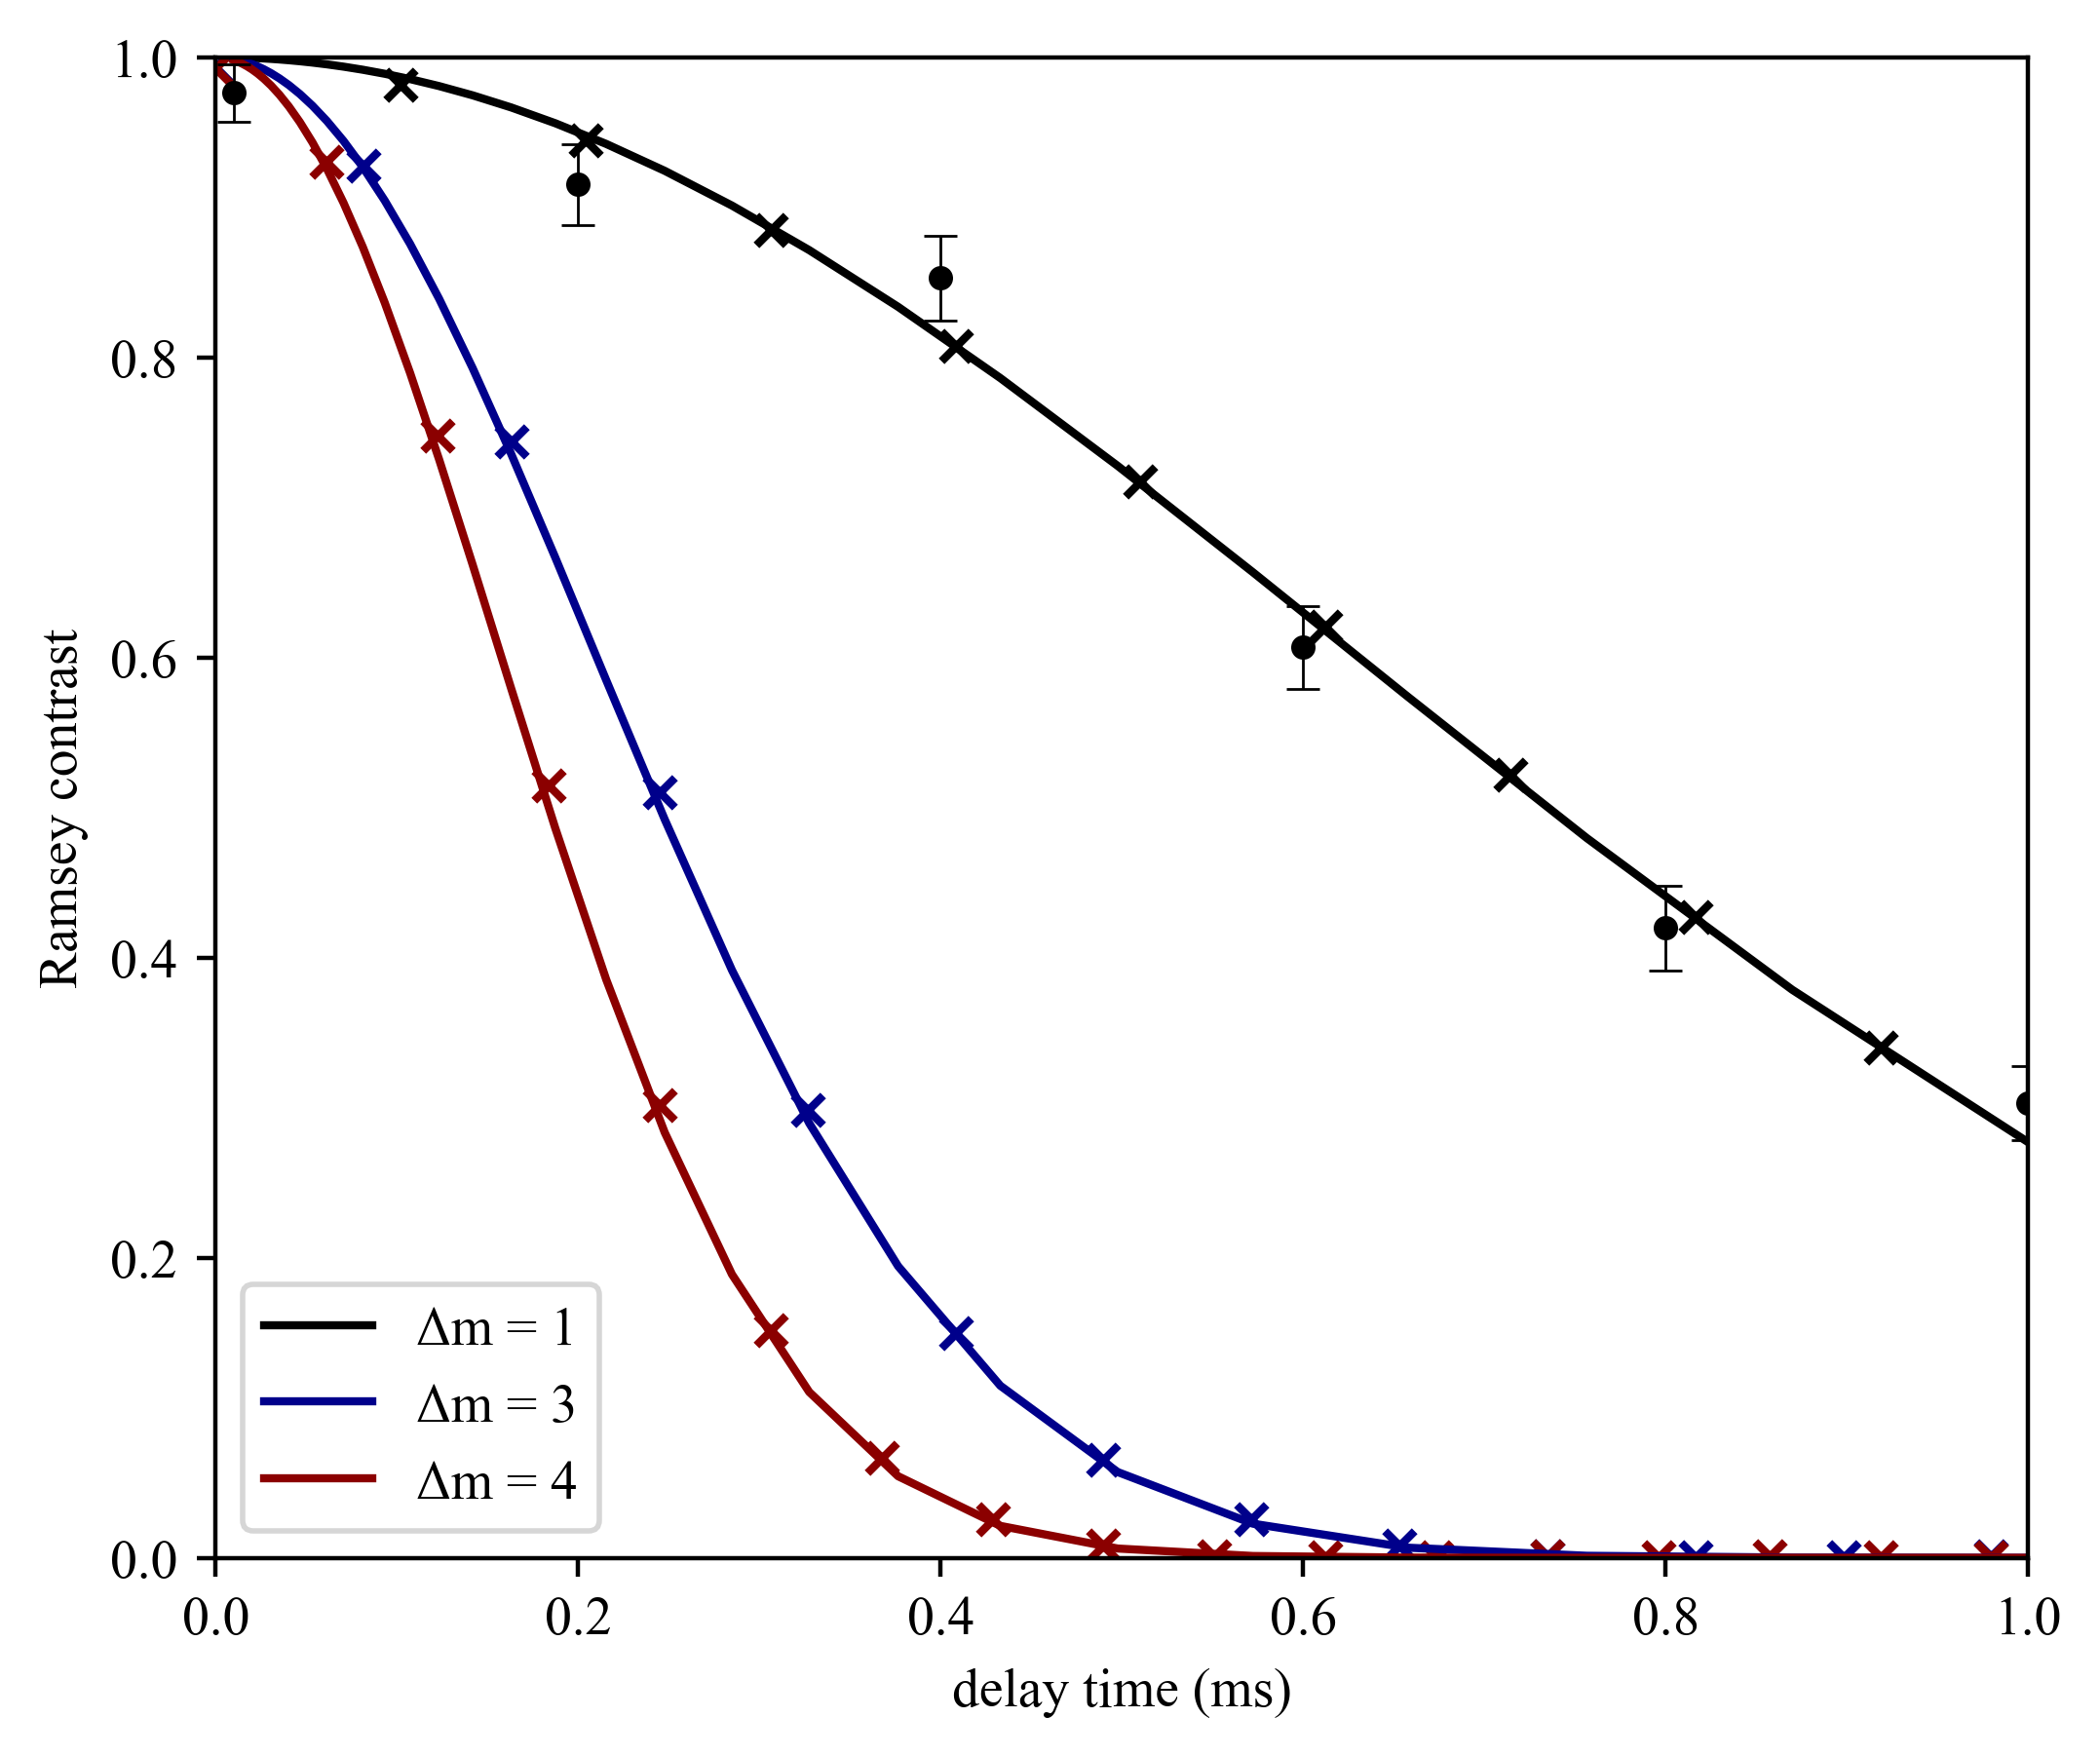

In [59]:
plt.figure(figsize = (6,5), dpi = 400)
plt.ylim(0,1)

plt.rcParams["font.family"] = "Times New Roman"
# plt.plot(t_fit*1e3, exp.Gaus(t_fit, σ1), color = 'black', 
#          label = 'Δm = 1, τ = '+ str(round(δ,3)) + ', Δm = 1, σ = '+ str(round(σ,3)))
# plt.plot(t_fit*1e3, exp.Gaus(t_fit, σ3), color = 'darkblue', 
#          label = 'Δm = 3, τ = '+ str(round(δ/3,3))+ ', Δm = 3, σ = '+ str(round(1/σ3,3)))
# plt.plot(t_fit*1e3, exp.Gaus(t_fit, σ4), color = 'darkred', 
#          label = 'Δm = 4, τ = '+ str(round(δ/4,3))+ ', Δm = 4, σ = '+ str(round(1/σ4,3)))

plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ1), color = 'black', 
         label = 'Δm = 1')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ3), color = 'darkblue', 
         label = 'Δm = 3')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ4), color = 'darkred', 
         label = 'Δm = 4')



plt.errorbar(ts*1e3, cs, yerr = δcs,marker = '.',
             ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
             ls='none', markersize=8, capsize=3, elinewidth = .5,markerfacecolor='black')
plt.legend(loc = 'lower left')

plt.scatter(sim1[0][::5]*1e3, sim1[1][::5], color = 'black', label = 'σ = '+str(round(σ*1e-3, 2))+' kHz',s = 30,marker = 'x')
plt.scatter(sim3[0][::4]*1e3, sim3[1][::4], color = 'darkblue', label = 'σ = '+str(round(σ*1e-3, 2))+' kHz',s = 30,marker = 'x')
plt.scatter(sim4[0][::3]*1e3, sim4[1][::3], color = 'darkred', label = 'σ = '+str(round(σ*1e-3, 2))+' kHz',s = 30,marker = 'x')


#plt.title('$|m_J=+5/2>$')
plt.xlabel('delay time (ms)')
plt.ylabel('Ramsey contrast')
plt.xlim(0,1)

In [57]:
# spin echoed contrast data from ruster paper

t_rust = np.array([
    0.0027, 0.0071, 0.0118, 0.0156, 0.0217, 0.0273, 0.0314,
    0.0375, 0.0434, 0.0492, 0.0565, 0.0627, 0.0697, 0.0761,
    0.0849, 0.0943, 0.1019, 0.1077, 0.1124, 0.1183, 0.1238,
    0.1282, 0.1347, 0.1405, 0.1478, 0.1546, 0.1616, 0.1777,
    0.1691, 0.1864, 0.1955, 0.2057, 0.2176, 0.2294, 0.2429,
    0.2581, 0.2751, 0.2943, 0.3178, 0.3465, 0.3832, 0.4355
])

c_rust = np.array([
    0.9835, 0.9880, 0.9748, 0.9880, 0.9891, 0.9892, 0.9397,
    0.9639, 0.9706, 0.9728, 0.9454, 0.9795, 0.9795, 0.9092,
    0.9675, 0.9840, 0.9313, 0.9731, 0.9380, 0.9545, 0.9523,
    0.9644, 0.9711, 0.9195, 0.9788, 0.9536, 0.9580, 0.9768,
    0.7548, 0.9021, 0.8945, 0.8594, 0.4001, 0.8243, 0.8794,
    0.9553, 0.9169, 0.6895, 0.7314, 0.9349, 0.4900, 0.1804
])



In [77]:
σg = .1
σ1_g = 0.6*σg
σ3_g = σ1_g/3
σ4_g = σ1_g/4

t_fit = np.logspace(-5,1,100)
y_fit_s = np.exp((-.5*(t_fit/σ1)**2))

p1, fit1, error1 = useful_funcs.fitGaus(t_rust,c_rust,[σ1_g])
δ = p1[0]*1e3*(2**.5)

σg = p1[0]
σ1_g = σg/.6
σ3_g = σ1_g/3
σ4_g = σ1_g/4

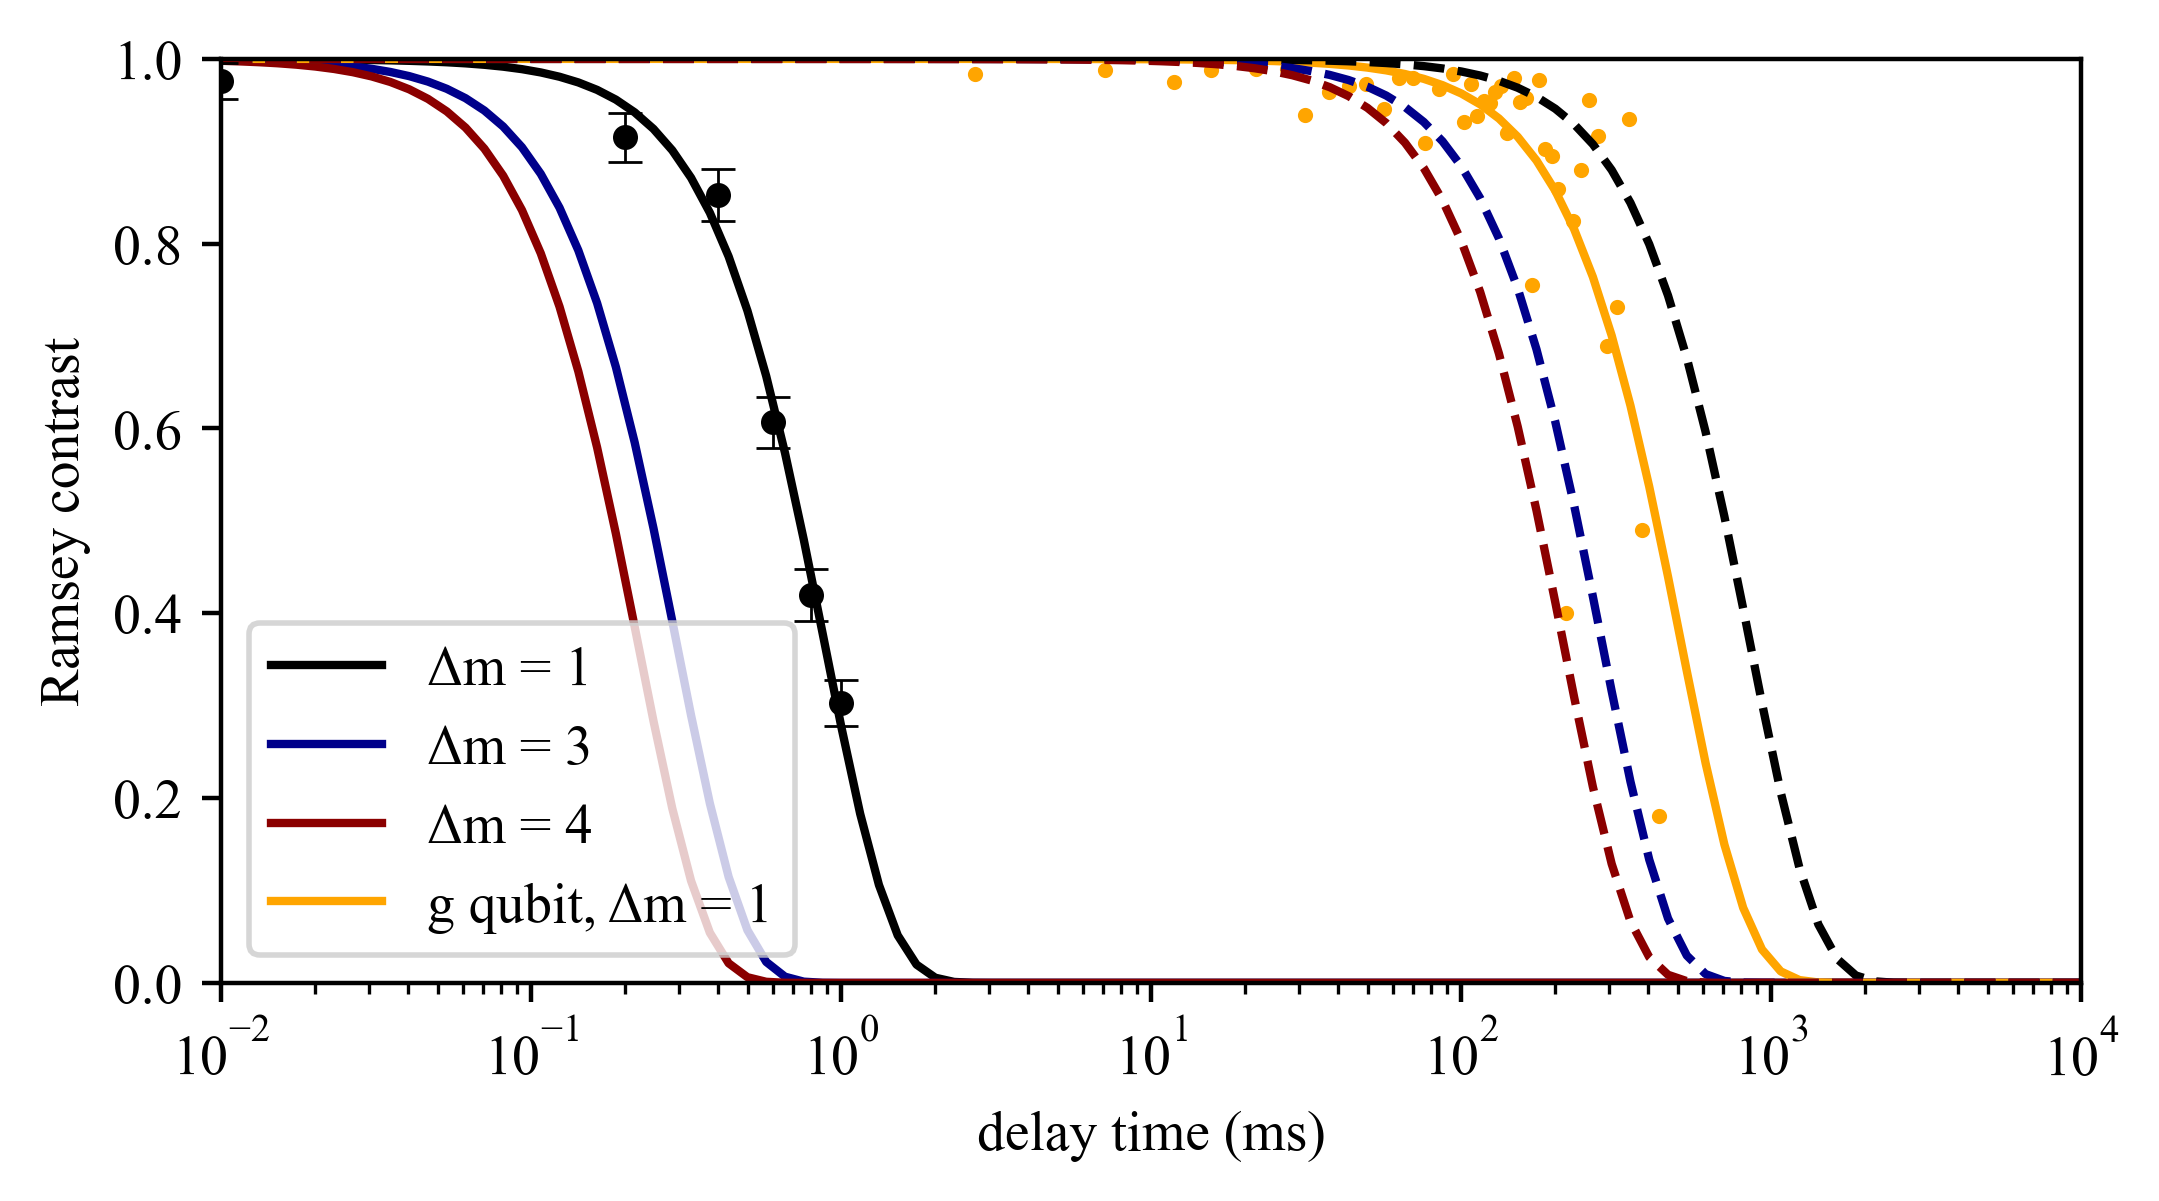

In [82]:
plt.figure(figsize = (6,3), dpi = 400)
plt.ylim(0,1)

plt.rcParams["font.family"] = "Times New Roman"
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ1), color = 'black', 
         label = 'Δm = 1')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ3), color = 'darkblue', 
         label = 'Δm = 3')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ4), color = 'darkred', 
         label = 'Δm = 4')

plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σg), color = 'orange', 
         label = 'g qubit, Δm = 1')

plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ1_g), color = 'black', linestyle = '--')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ3_g), color = 'darkblue', linestyle = '--')
plt.plot(t_fit*1e3, useful_funcs.Gaus(t_fit, σ4_g), color = 'darkred', linestyle = '--')

plt.errorbar(ts*1e3, cs, yerr = δcs,marker = '.',
             ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
             ls='none', markersize=8, capsize=3, elinewidth = .5,markerfacecolor='black')
plt.scatter(t_rust*1e3, c_rust, color = 'orange', s = 3)
plt.legend(loc = 'lower left')




#plt.title('$|m_J=+5/2>$')
plt.xlabel('delay time (ms)')
plt.ylabel('Ramsey contrast')
plt.xlim(1e-2,1e4)
plt.xscale('log')
plt.show()
